# Comparison of SVM and Deep Learning Models

H3_7 is the best performing spatial unit for the Neural Network and the second best for SVM. For the NN it is the hourly level and for the SVM it is the daily level though. We will compare the models for both temporal levels against each other and the base line on the test set.

Rather than re-loading and re-running the models, this notebook loads only their already-computed predictions on the held-out
test split plus the historical-mean baseline.

All three signals (baseline, SVM, NN) live as columns of a single testing_df, so each cell is just a different slice/aggregation of that one frame.

In [1]:
import warnings
from pathlib import Path

import numpy as np
import pandas as pd
import h3
import geopandas as gpd
import contextily as ctx
import shapely
import mapclassify
import matplotlib.pyplot as plt
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score, root_mean_squared_error

warnings.filterwarnings("ignore", category=UserWarning)
warnings.filterwarnings("ignore", message="Mean of empty slice")
RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

INDEX = "h3_index_7"
TRUTH = "y_true"
BASELINE_COL = "base_demand"

SVR_DIR = Path("../models_predictions/SVR/residual/predictions")
FNN_DIR = Path("../models_predictions/FNN/standard/h3_7")

predictions = {
    "svm": {"col": "y_pred_svr", "name": "Best SVM (Residual SVR)"},
    "nn": {"col": "y_pred_fnn", "name": "Neural Network (FNN)"},
}

def score(y_true, y_pred, name):
    return {
        "Model": name,
        "MAE": mean_absolute_error(y_true, y_pred),
        "RMSE": np.sqrt(mean_squared_error(y_true, y_pred)),
        "R2": r2_score(y_true, y_pred),
    }

def load_comparison(temporal):
    svr = pd.read_parquet(SVR_DIR / f"test_pred_h3_7_{temporal}.parquet")
    fnn = pd.read_parquet(FNN_DIR / f"FNN_h3_7_{temporal}.parquet")
    svr.rename(columns={"Total_Trip_Start": "y_true", "SVR_pred": "y_pred"}, inplace=True)
    # Merge on spatial unit + time only
    # Keep a single y_true column, taken from the SVR file, and drop the FNN copy before merging.
    fnn = fnn.drop(columns="y_true")
    merged = svr.merge(fnn, on=[INDEX, "timestamp"], suffixes=("_svr", "_fnn"))
    return merged

comparisons = {
    "daily": load_comparison("daily"),
    "hourly": load_comparison("hourly"),
}

print("Loaded:")
for temporal, df in comparisons.items():
    print(f"h3_7/{temporal}: {len(df)} rows")

Loaded:
h3_7/daily: 27972 rows
h3_7/hourly: 671328 rows


## Performance Metrics Table

Historical-mean baseline (`base_demand`) plus the best SVM and the neural network, scored on the
full `h3_7/daily` held-out **test** set.

In [2]:
#| label: tbl-svm-vs-nn-overall
#| tbl-cap: "Overall TEST performance at h3_7/daily and h3_7/hourly."
#| tbl-subcap:
#|   - "h3_7/daily"
#|   - "h3_7/hourly"
for temporal, testing_df in comparisons.items():
    print(f"\n H3_7/{temporal}")
    rows = [score(testing_df[TRUTH].values, testing_df[BASELINE_COL].values, "Baseline")]
    for p in predictions.values():
        rows.append(score(testing_df[TRUTH].values, testing_df[p["col"]].values, p["name"]))
    display(pd.DataFrame(rows).set_index("Model").round(4))


 H3_7/daily


,MAE,RMSE,R2
Model,,,
Baseline,21.3913,121.0296,0.9061
Best SVM (Residual SVR),20.6391,112.3737,0.9190
Neural Network (FNN),20.1520,118.8802,0.9094



 H3_7/hourly


,MAE,RMSE,R2
Model,,,
Baseline,1.0678,7.4296,0.8805
Best SVM (Residual SVR),1.0165,6.4802,0.9091
Neural Network (FNN),0.9767,6.4700,0.9094


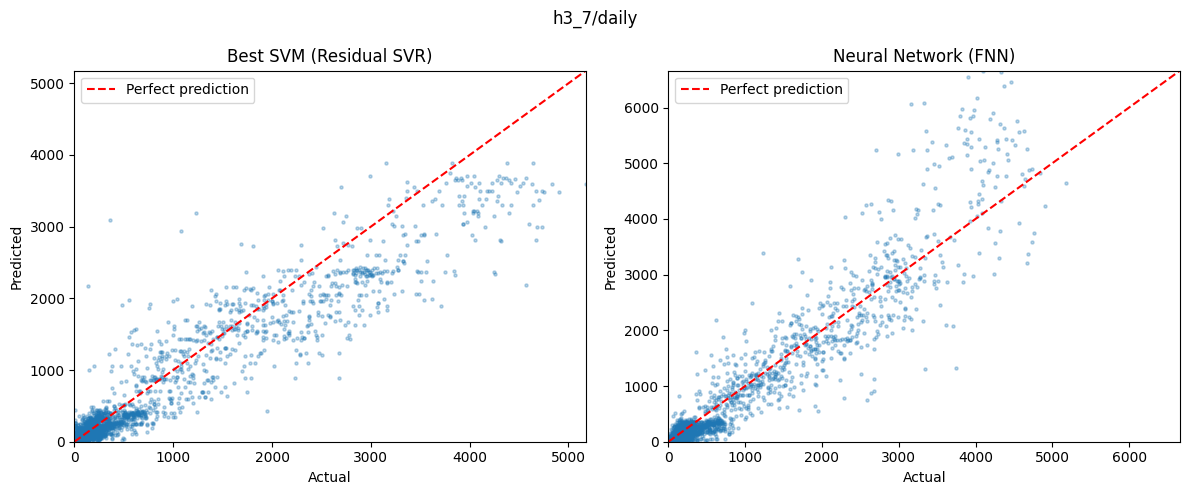

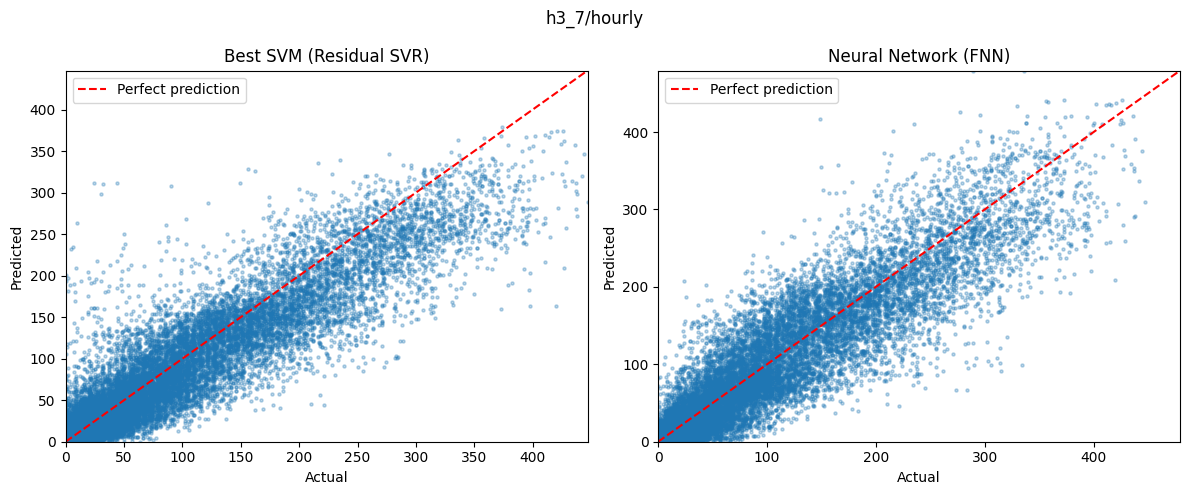

In [3]:
#| label: fig-svm-vs-nn-scatter
#| fig-cap: "Actual vs. predicted demand per temporal resolution."
#| fig-subcap:
#|   - "h3_7/daily"
#|   - "h3_7/hourly"
#| layout-ncol: 1
for temporal, testing_df in comparisons.items():
    y_true = testing_df[TRUTH].values
    fig, axes = plt.subplots(1, len(predictions), figsize=(6 * len(predictions), 5), squeeze=False)
    fig.suptitle(f"h3_7/{temporal}")
    for ax, (key, p) in zip(axes[0], predictions.items()):
        pred = testing_df[p["col"]].values
        lim = max(y_true.max(), pred.max())
        ax.scatter(y_true, pred, alpha=0.3, s=5)
        ax.plot([0, lim], [0, lim], "r--", label="Perfect prediction")
        ax.set_xlim(0, lim)
        ax.set_ylim(0, lim)
        ax.set_xlabel("Actual")
        ax.set_ylabel("Predicted")
        ax.set_title(p["name"])
        ax.legend()
    plt.tight_layout()
    plt.show()

## Spatial Prediction Quality

The aggregate metrics above collapse the whole city into a single number and hide strong
**spatial** variation in how well each model performs. Here we aggregate error by H3 hexagon and
compare whichever of the SVM / the neural network are available, side by side.

- **MAE per hexagon**: The absolute size of the prediction miss (trips/day).
- **Relative error per hexagon**: The miss size relative to that cell's own mean demand.
- **R² per hexagon** How much of each cell's day-to-day demand variation the model explains. (Cells whose demand is essentially flat have no variation to explain, so their R² is undefined and they are greyed out.)

In [4]:
# Community area outlines, used as a spatial reference overlay in the choropleths.
tracts = gpd.read_file(Path("..") / "data" / "chicago_census_comm.gpkg")
community_areas = tracts.dissolve(by="commarea")


def get_hexagon_grid(data, h3_col="h3_index"):
    """Build a GeoDataFrame of H3 hexagon polygons, preserving all columns from the source."""
    def _to_polygon(cell):
        boundary = h3.cell_to_boundary(cell)
        return shapely.geometry.Polygon([(lng, lat) for lat, lng in boundary])

    if isinstance(data, pd.Series):
        df = pd.DataFrame({"h3_index": list(data)})
        h3_list = df["h3_index"]
    else:
        df = data.reset_index(drop=True)
        h3_list = df[h3_col]
    geometries = [_to_polygon(c) for c in h3_list]
    return gpd.GeoDataFrame(df, geometry=geometries, crs="EPSG:4326")


def get_hexagon_performance_metrics(df_eval, pred_col, target_col=TRUTH, h3_col="h3_index_7"):
    """Compute MAE/RMSE/R2/relative-error per hexagon for one prediction column."""
    d = df_eval.assign(
        abs_err=(df_eval[target_col] - df_eval[pred_col]).abs(),
        sq_err=(df_eval[target_col] - df_eval[pred_col]) ** 2,
    )
    grp = d.groupby(h3_col)
    hex_perf = grp.agg(
        n_obs=(target_col, "size"),
        mean_actual=(target_col, "mean"),
        var_actual=(target_col, "var"),
        mae=("abs_err", "mean"),
        mse=("sq_err", "mean"),
    )
    hex_perf["rmse"] = np.sqrt(hex_perf["mse"])
    ss_res = grp["sq_err"].sum()
    ss_tot = hex_perf["var_actual"].fillna(0) * (hex_perf["n_obs"] - 1)
    hex_perf["r2"] = 1 - ss_res / ss_tot.replace(0, np.nan)
    hex_perf["rel_error"] = hex_perf["mae"] / hex_perf["mean_actual"].replace(0, np.nan)
    hex_perf = hex_perf.drop(columns=["var_actual", "mse"]).reset_index()
    hex_perf_gdf = get_hexagon_grid(hex_perf, h3_col=h3_col)
    return hex_perf, hex_perf_gdf


def shared_quantile_bins(gdfs, value_col, k=7):
    """Quantile bin edges pooled over every gdf's `value_col`, so all subplots in a figure share
    one classification (identical colors + legend) and are directly comparable."""
    pooled = pd.concat([gdf[value_col] for gdf in gdfs]).replace([np.inf, -np.inf], np.nan).dropna()
    return mapclassify.Quantiles(pooled, k=k).bins


def create_choropleth_plot(ax, gdf, value_col, title="", cmap="YlOrRd", k=7, bins=None):
    """Plot one quantile choropleth of a hexagon-level metric onto ax, with a Chicago basemap and
    community-area boundary overlay. Pass `bins` (from `shared_quantile_bins`) to force a fixed
    classification shared across subplots so their legends line up for comparison."""
    if bins is not None:
        scheme_kwds = dict(scheme="UserDefined", classification_kwds={"bins": list(bins)})
    else:
        scheme_kwds = dict(scheme="quantiles", k=k)
    gdf.to_crs(epsg=3857).plot(
        ax=ax, column=value_col, cmap=cmap,
        edgecolor="none", alpha=0.8, legend=True, zorder=1,
        legend_kwds=dict(title=value_col.replace("_", " ").title(),
                         loc="lower right", fontsize=8, title_fontsize=9),
        missing_kwds=dict(color="lightgrey", label="No data"),
        **scheme_kwds,
    )
    ctx.add_basemap(ax, source=ctx.providers.CartoDB.PositronNoLabels, zoom=11)
    community_areas.to_crs(epsg=3857).boundary.plot(ax=ax, color="#222", linewidth=1.0, alpha=0.9, zorder=3)
    ax.set_axis_off()
    ax.set_title(title, fontsize=12, fontweight="bold", pad=10)

In [5]:
# (hex_perf, hex_gdf) per model, keyed the same way as `predictions`. Computed on the test set.
hex_data = {key: get_hexagon_performance_metrics(testing_df, pred_col=p["col"], h3_col="h3_index_7")
           for key, p in predictions.items()}

### Map 1: mean absolute error (MAE) per hexagon

Because demand itself is far higher downtown, the largest absolute errors concentrate in the Loop;
the quiet outskirts have tiny MAE simply because there is little demand.


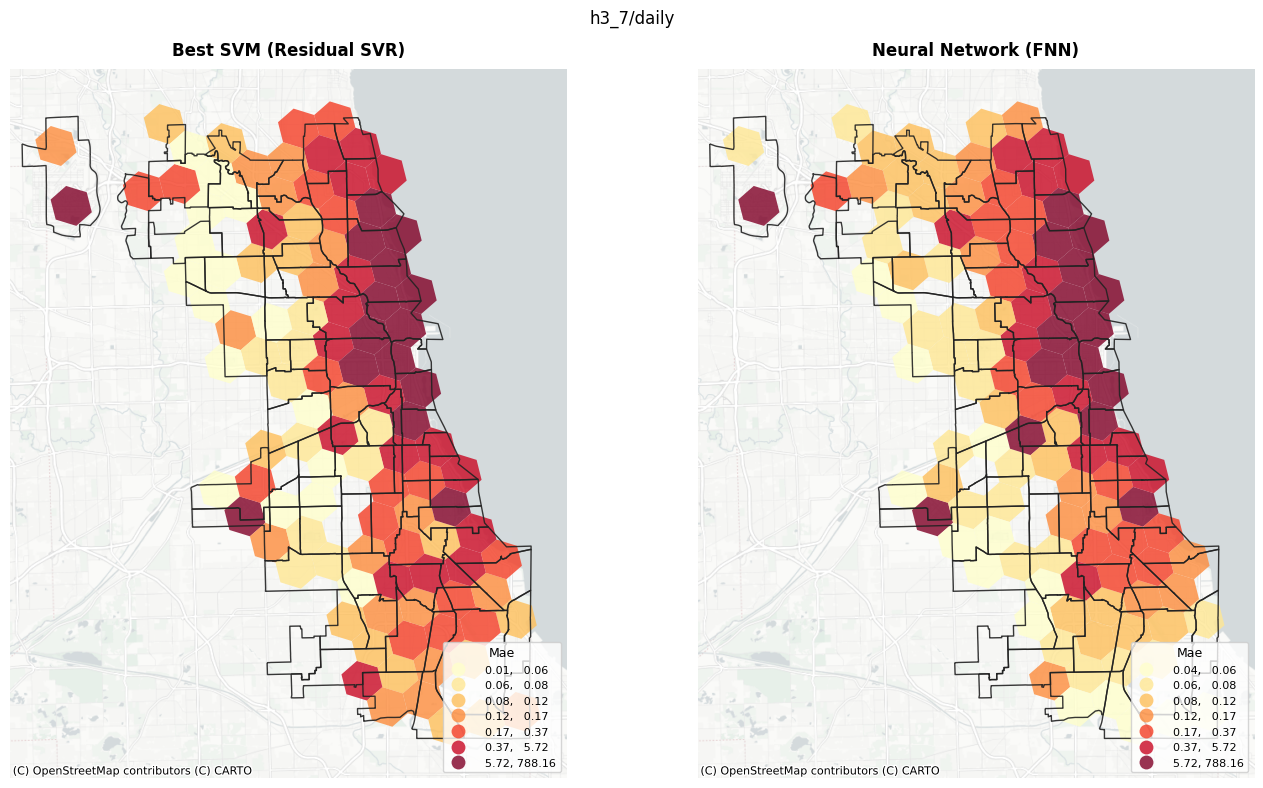

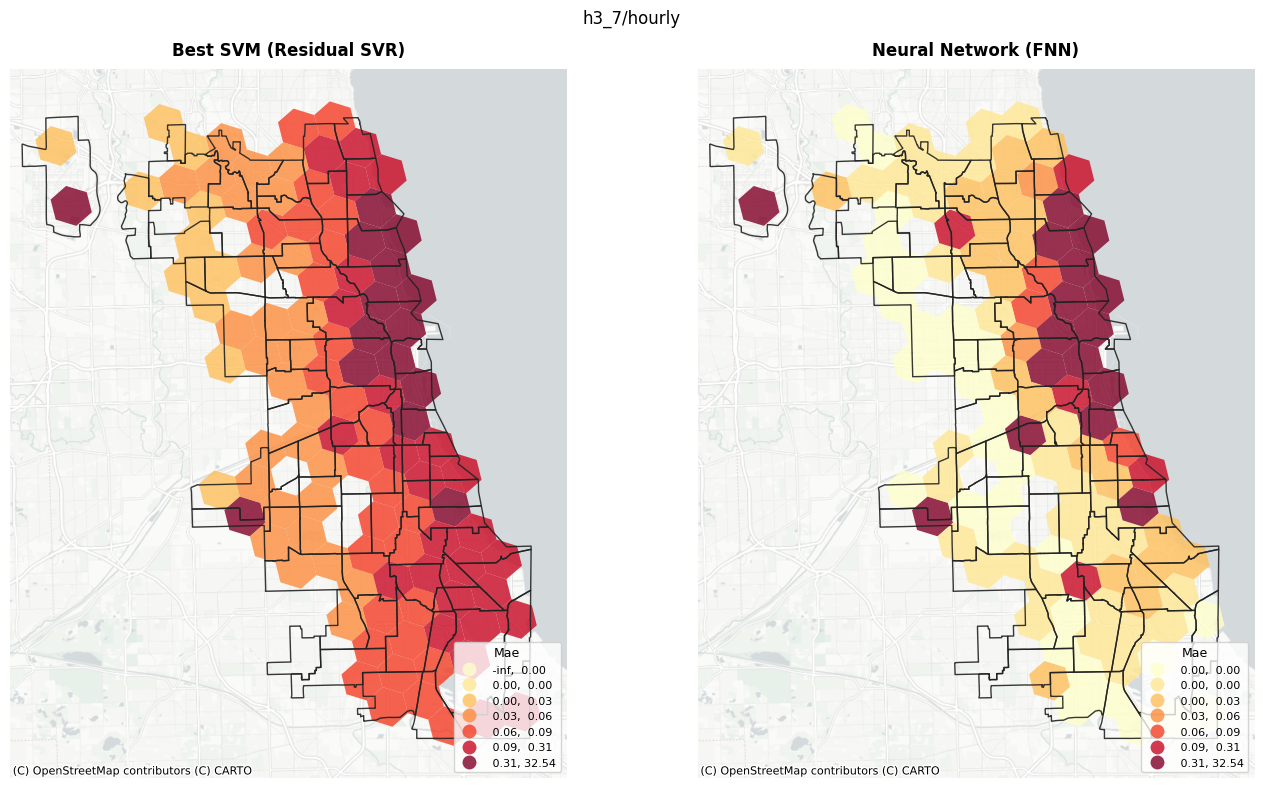

In [6]:
#| label: fig-svm-hex-mae
#| fig-cap: "MAE per hexagon per temporal resolution."
#| fig-subcap:
#|   - "h3_7/daily"
#|   - "h3_7/hourly"
#| layout-ncol: 1
for temporal, testing_df in comparisons.items():
    hex_data = {key: get_hexagon_performance_metrics(testing_df, pred_col=p["col"], h3_col=INDEX)
                for key, p in predictions.items()}
    bins = shared_quantile_bins([gdf for (_, gdf) in hex_data.values()], "mae")
    fig, axes = plt.subplots(1, len(hex_data), figsize=(7 * len(hex_data), 8), squeeze=False)
    fig.suptitle(f"h3_7/{temporal}")
    for ax, (key, (_, gdf)) in zip(axes[0], hex_data.items()):
        create_choropleth_plot(ax, gdf, "mae", title=predictions[key]["name"], bins=bins)
    plt.tight_layout()
    plt.show()


### Map 2: mean relative error (MRE) per hexagon

The miss size relative to each cell's own mean demand -- this is what makes small-demand
outskirts visible instead of always looking "perfect" on raw MAE alone.


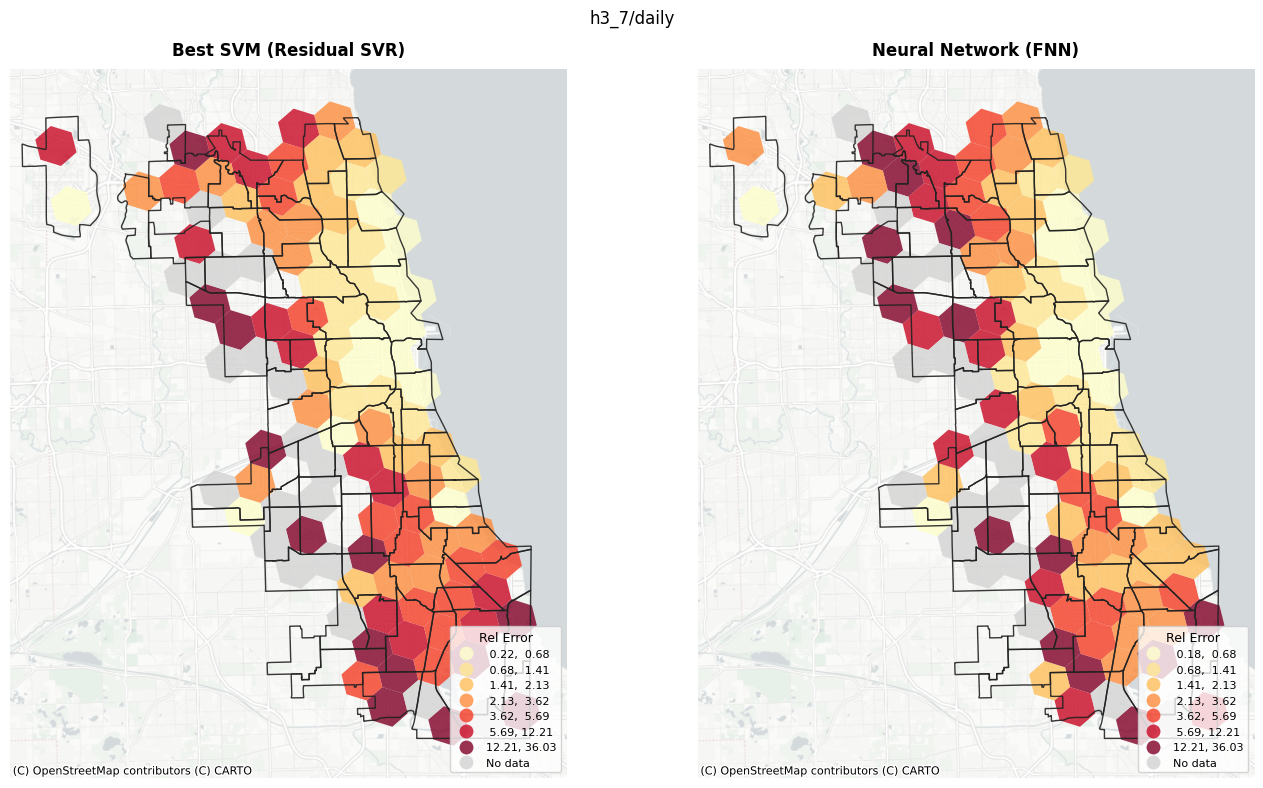

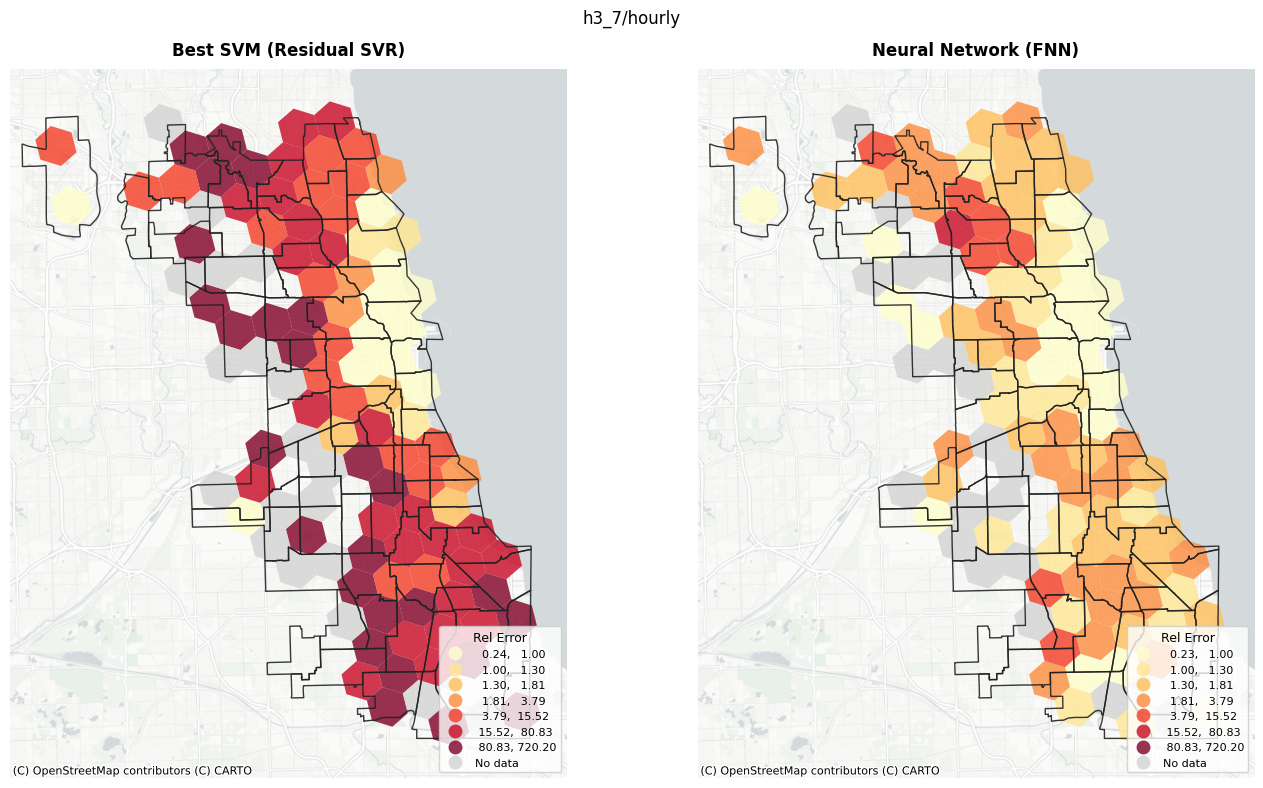

In [7]:
#| label: fig-svm-hex-mre
#| fig-cap: "Relative error per hexagon per temporal resolution."
#| fig-subcap:
#|   - "h3_7/daily"
#|   - "h3_7/hourly"
#| layout-ncol: 1
for temporal, testing_df in comparisons.items():
    hex_data = {key: get_hexagon_performance_metrics(testing_df, pred_col=p["col"], h3_col=INDEX)
                for key, p in predictions.items()}
    bins = shared_quantile_bins([gdf for (_, gdf) in hex_data.values()], "rel_error")
    fig, axes = plt.subplots(1, len(hex_data), figsize=(7 * len(hex_data), 8), squeeze=False)
    fig.suptitle(f"h3_7/{temporal}")
    for ax, (key, (_, gdf)) in zip(axes[0], hex_data.items()):
        create_choropleth_plot(ax, gdf, "rel_error", title=predictions[key]["name"], bins=bins)
    plt.tight_layout()
    plt.show()


### Map 3: coefficient of determination (R2) per hexagon

Green = the day-to-day demand pattern is captured well; red = poorly; grey = too little demand
variation to assess.


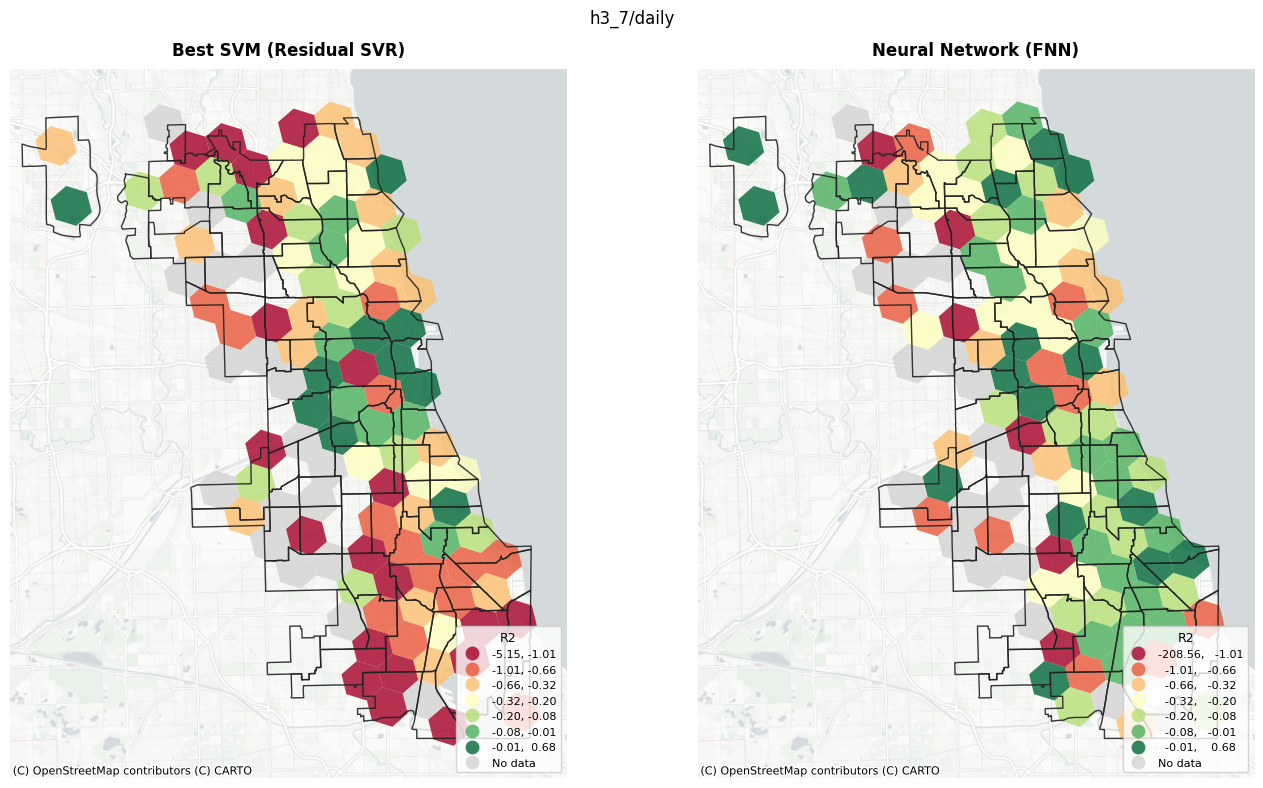

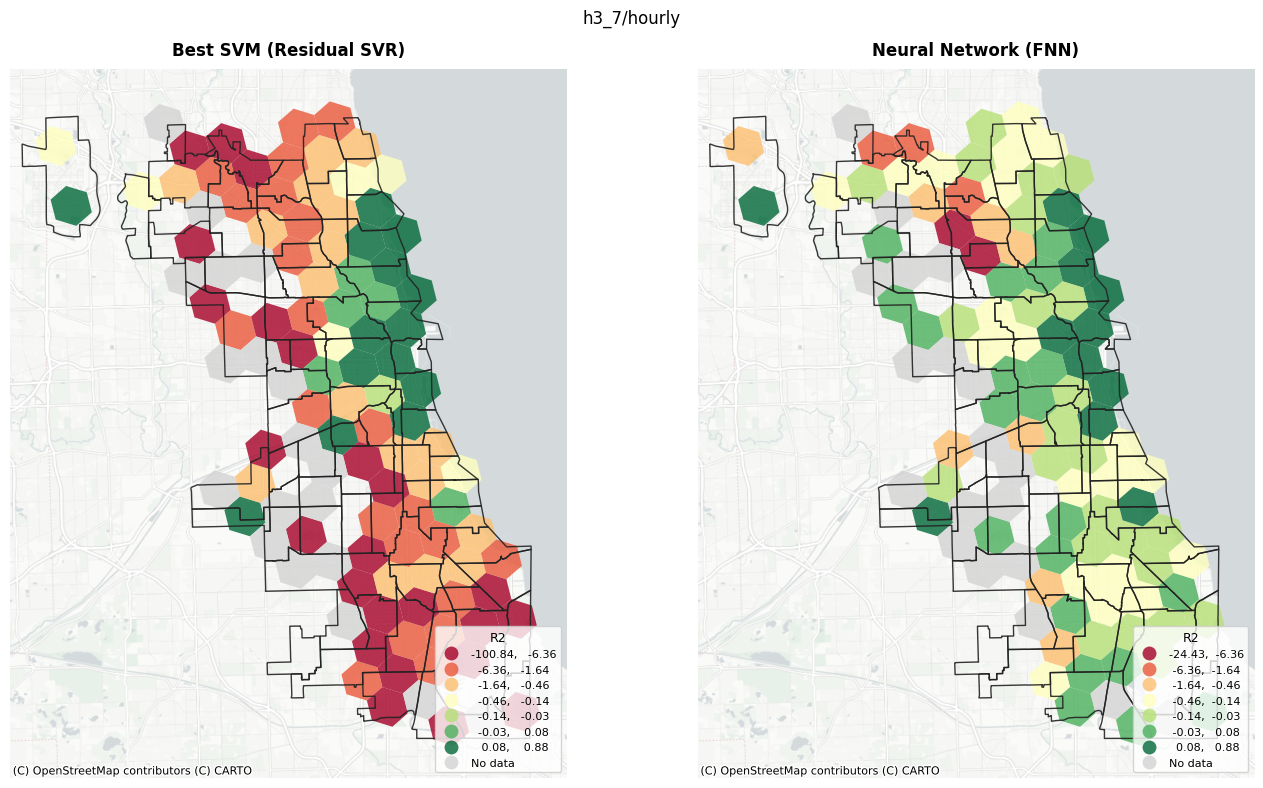

In [8]:
#| label: fig-svm-hex-r2
#| fig-cap: "R² per hexagon per temporal resolution."
#| fig-subcap:
#|   - "h3_7/daily"
#|   - "h3_7/hourly"
#| layout-ncol: 1
for temporal, testing_df in comparisons.items():
    hex_data = {key: get_hexagon_performance_metrics(testing_df, pred_col=p["col"], h3_col=INDEX)
                for key, p in predictions.items()}
    bins = shared_quantile_bins([gdf for (_, gdf) in hex_data.values()], "r2")
    fig, axes = plt.subplots(1, len(hex_data), figsize=(7 * len(hex_data), 8), squeeze=False)
    fig.suptitle(f"h3_7/{temporal}")
    for ax, (key, (_, gdf)) in zip(axes[0], hex_data.items()):
        create_choropleth_plot(ax, gdf, "r2", title=predictions[key]["name"], cmap="RdYlGn", bins=bins)
    plt.tight_layout()
    plt.show()


### Map 4: where does one model beat the other?

The three maps above put the SVM and the NN side by side, but reading "who wins where" off two separate color scales is hard. This map plots the difference directly:

`MAE_NN - MAE_SVM` per hexagon. 
**Blue means the SVM has the lower error there (SVM wins); Red means the NN does.**

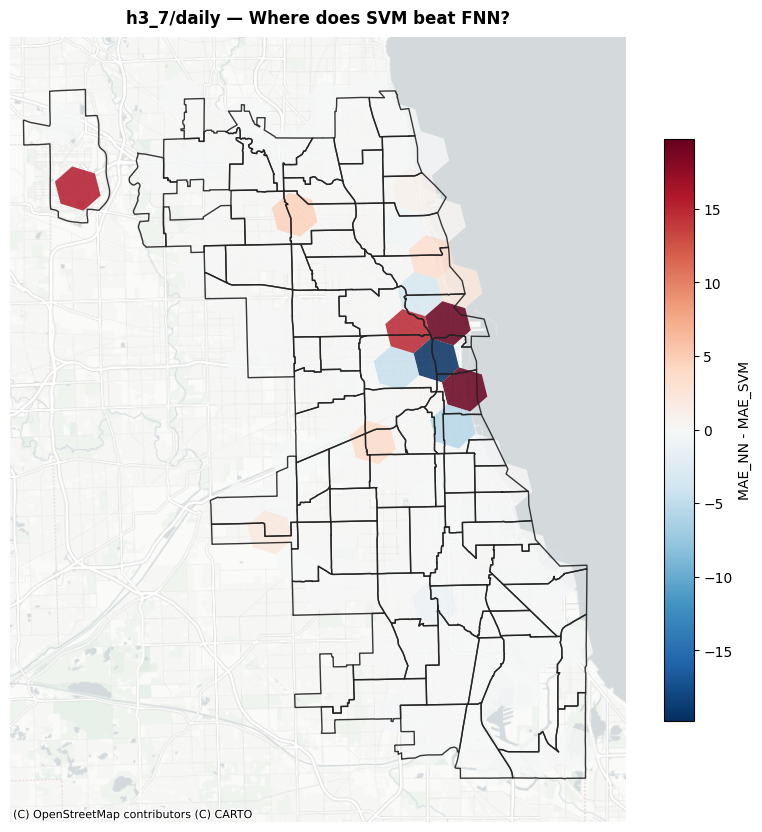

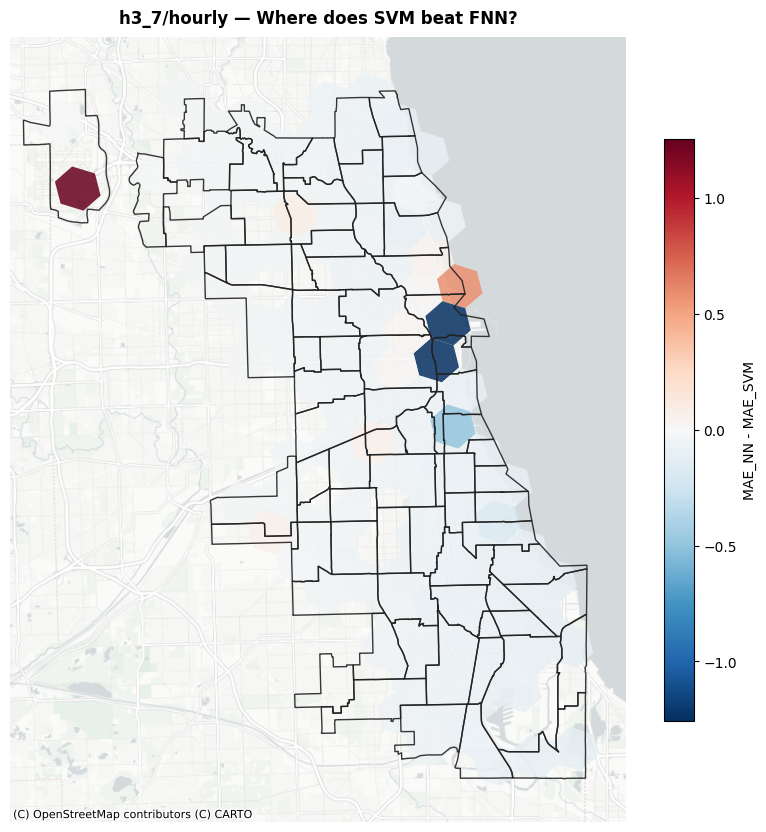

In [9]:
#| label: fig-svm-vs-nn-hex-delta
#| fig-cap: "MAE_NN - MAE_SVM per hexagon per temporal resolution. Blue = SVM wins, red = FNN wins."
#| fig-subcap:
#|   - "h3_7/daily"
#|   - "h3_7/hourly"
#| layout-ncol: 1
for temporal, testing_df in comparisons.items():
    hex_data = {key: get_hexagon_performance_metrics(testing_df, pred_col=p["col"], h3_col=INDEX)
                for key, p in predictions.items()}
    hex_perf_svm, _ = hex_data["svm"]
    hex_perf_nn, _ = hex_data["nn"]
    delta = hex_perf_svm[[INDEX, "mae"]].merge(hex_perf_nn[[INDEX, "mae"]], on=INDEX, suffixes=("_svm", "_nn"))
    delta["mae_delta"] = delta["mae_nn"] - delta["mae_svm"]
    delta_gdf = get_hexagon_grid(delta, h3_col=INDEX)
    bmax = delta_gdf["mae_delta"].abs().quantile(0.98)
    fig, ax = plt.subplots(figsize=(8, 10))
    delta_gdf.to_crs(epsg=3857).plot(
        ax=ax, column="mae_delta", cmap="RdBu_r", vmin=-bmax, vmax=bmax,
        edgecolor="none", alpha=0.85, legend=True, zorder=1,
        legend_kwds=dict(label="MAE_NN - MAE_SVM", shrink=0.6),
    )
    ctx.add_basemap(ax, source=ctx.providers.CartoDB.PositronNoLabels, zoom=11)
    community_areas.to_crs(epsg=3857).boundary.plot(ax=ax, color="#222", linewidth=1.0, alpha=0.9, zorder=3)
    ax.set_axis_off()
    ax.set_title(f"h3_7/{temporal} — Where does SVM beat FNN?", fontsize=12, fontweight="bold", pad=10)
    plt.tight_layout()
    plt.show()


## Time Performance Analysis

H3_7/daily has no hour-of-day feature (each row is already a full day), so the temporal
breakdown by day of week below covers both resolutions, while the hour-of-day breakdown that
follows only applies to `h3_7/hourly`.

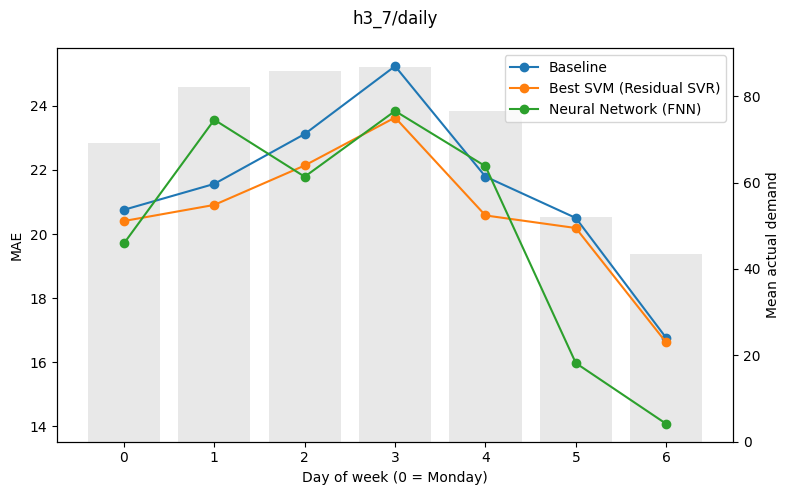

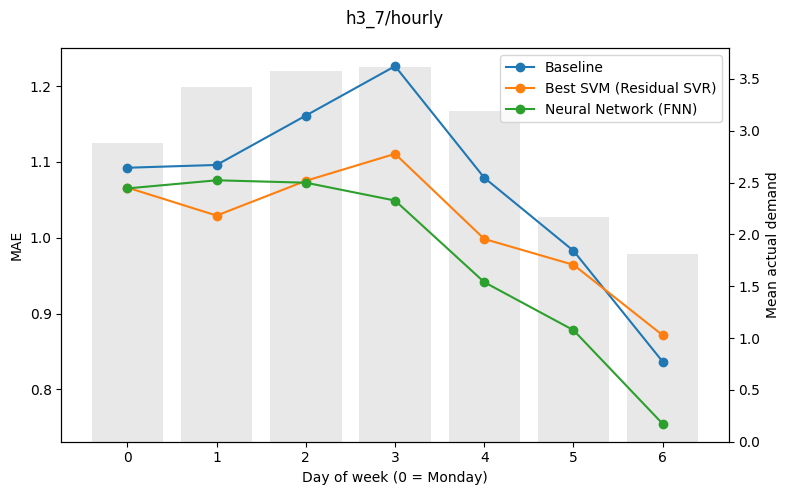

In [10]:
#| label: fig-svm-vs-nn-dayofweek
#| fig-cap: "Test MAE by day of week per temporal resolution."
#| fig-subcap:
#|   - "h3_7/daily"
#|   - "h3_7/hourly"
#| layout-ncol: 1
for temporal, testing_df in comparisons.items():
    by_d = testing_df.groupby("day_of_week").apply(
        lambda g: pd.Series({
            "Baseline": mean_absolute_error(g[TRUTH], g[BASELINE_COL]),
            **{p["name"]: mean_absolute_error(g[TRUTH], g[p["col"]]) for p in predictions.values()},
            "mean_demand": g[TRUTH].mean(),
        }), include_groups=False)

    fig, ax = plt.subplots(figsize=(8, 5))
    fig.suptitle(f"h3_7/{temporal}")
    ax2 = ax.twinx()
    ax2.bar(by_d.index, by_d["mean_demand"], color="lightgray", alpha=0.5)
    ax2.set_ylabel("Mean actual demand")
    ax.plot(by_d.index, by_d["Baseline"], marker="o", label="Baseline")
    for p in predictions.values():
        ax.plot(by_d.index, by_d[p["name"]], marker="o", label=p["name"])
    ax.set_xlabel("Day of week (0 = Monday)")
    ax.set_ylabel("MAE")
    ax.set_xticks(range(7))
    ax.set_zorder(ax2.get_zorder() + 1)
    ax.patch.set_visible(False)
    ax.legend()
    plt.tight_layout()
    plt.show()

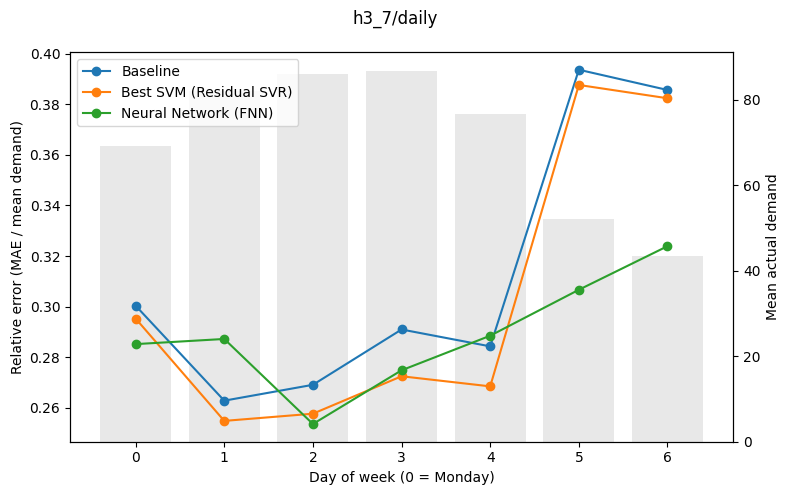

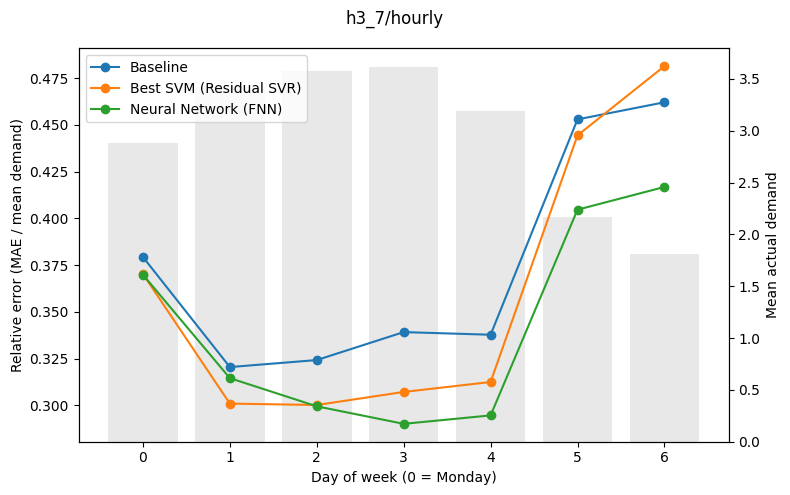

In [11]:
#| label: fig-svm-vs-nn-dayofweek-relerr
#| fig-cap: "Test relative error (MAE / mean demand) by day of week per temporal resolution."
#| fig-subcap:
#|   - "h3_7/daily"
#|   - "h3_7/hourly"
#| layout-ncol: 1
for temporal, testing_df in comparisons.items():
    by_d = testing_df.groupby("day_of_week").apply(
        lambda g: pd.Series({
            "Baseline": mean_absolute_error(g[TRUTH], g[BASELINE_COL]) / g[TRUTH].mean(),
            **{p["name"]: mean_absolute_error(g[TRUTH], g[p["col"]]) / g[TRUTH].mean()
               for p in predictions.values()},
            "mean_demand": g[TRUTH].mean(),
        }), include_groups=False)

    fig, ax = plt.subplots(figsize=(8, 5))
    fig.suptitle(f"h3_7/{temporal}")
    ax2 = ax.twinx()
    ax2.bar(by_d.index, by_d["mean_demand"], color="lightgray", alpha=0.5)
    ax2.set_ylabel("Mean actual demand")
    ax.plot(by_d.index, by_d["Baseline"], marker="o", label="Baseline")
    for p in predictions.values():
        ax.plot(by_d.index, by_d[p["name"]], marker="o", label=p["name"])
    ax.set_xlabel("Day of week (0 = Monday)")
    ax.set_ylabel("Relative error (MAE / mean demand)")
    ax.set_xticks(range(7))
    ax.set_zorder(ax2.get_zorder() + 1)
    ax.patch.set_visible(False)
    ax.legend()
    plt.tight_layout()
    plt.show()

### Error throughout the day

Only H3_7/Hourly carries an hour_of_day feature, so this breakdown is hourly-only. It shows
whether errors concentrate around commute peaks (roughly 7-9 and 16-19) or overnight, when demand
is near zero and even small absolute misses can dominate relative error.

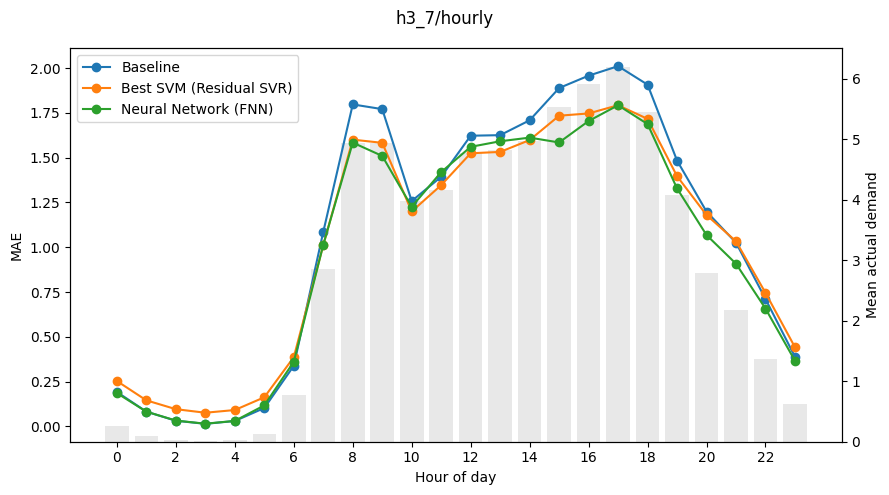

In [12]:
#| label: fig-svm-vs-nn-hourofday
#| fig-cap: "Test MAE by hour of day (h3_7/hourly)."
testing_df = comparisons["hourly"]
by_h = testing_df.groupby("hour_of_day").apply(
    lambda g: pd.Series({
        "Baseline": mean_absolute_error(g[TRUTH], g[BASELINE_COL]),
        **{p["name"]: mean_absolute_error(g[TRUTH], g[p["col"]]) for p in predictions.values()},
        "mean_demand": g[TRUTH].mean(),
    }), include_groups=False)

fig, ax = plt.subplots(figsize=(9, 5))
fig.suptitle("h3_7/hourly")
ax2 = ax.twinx()
ax2.bar(by_h.index, by_h["mean_demand"], color="lightgray", alpha=0.5)
ax2.set_ylabel("Mean actual demand")
ax.plot(by_h.index, by_h["Baseline"], marker="o", label="Baseline")
for p in predictions.values():
    ax.plot(by_h.index, by_h[p["name"]], marker="o", label=p["name"])
ax.set_xlabel("Hour of day")
ax.set_ylabel("MAE")
ax.set_xticks(range(0, 24, 2))
ax.set_zorder(ax2.get_zorder() + 1)
ax.patch.set_visible(False)
ax.legend()
plt.tight_layout()
plt.show()

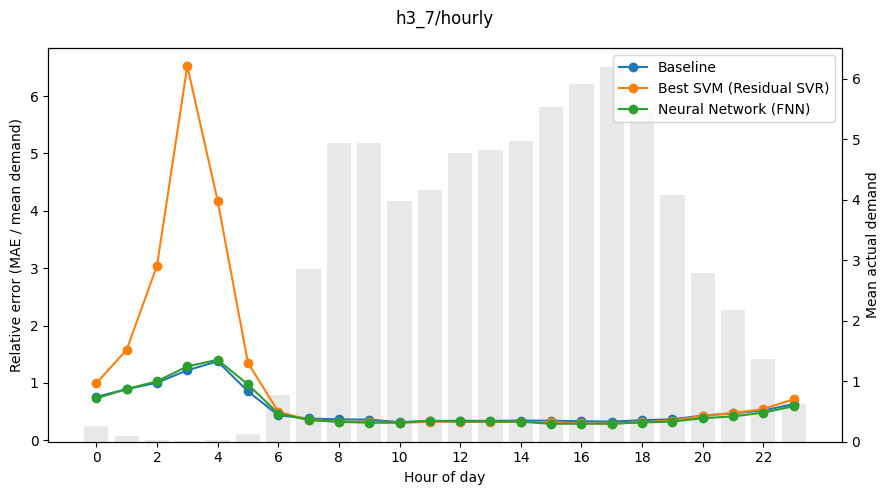

In [13]:
#| label: fig-svm-vs-nn-hourofday-relerr
#| fig-cap: "Test relative error (MAE / mean demand) by hour of day (h3_7/hourly)."
testing_df = comparisons["hourly"]
by_h = testing_df.groupby("hour_of_day").apply(
    lambda g: pd.Series({
        "Baseline": mean_absolute_error(g[TRUTH], g[BASELINE_COL]) / g[TRUTH].mean(),
        **{p["name"]: mean_absolute_error(g[TRUTH], g[p["col"]]) / g[TRUTH].mean()
           for p in predictions.values()},
        "mean_demand": g[TRUTH].mean(),
    }), include_groups=False)

fig, ax = plt.subplots(figsize=(9, 5))
fig.suptitle("h3_7/hourly")
ax2 = ax.twinx()
ax2.bar(by_h.index, by_h["mean_demand"], color="lightgray", alpha=0.5)
ax2.set_ylabel("Mean actual demand")
ax.plot(by_h.index, by_h["Baseline"], marker="o", label="Baseline")
for p in predictions.values():
    ax.plot(by_h.index, by_h[p["name"]], marker="o", label=p["name"])
ax.set_xlabel("Hour of day")
ax.set_ylabel("Relative error (MAE / mean demand)")
ax.set_xticks(range(0, 24, 2))
ax.set_zorder(ax2.get_zorder() + 1)
ax.patch.set_visible(False)
ax.legend()
plt.tight_layout()
plt.show()

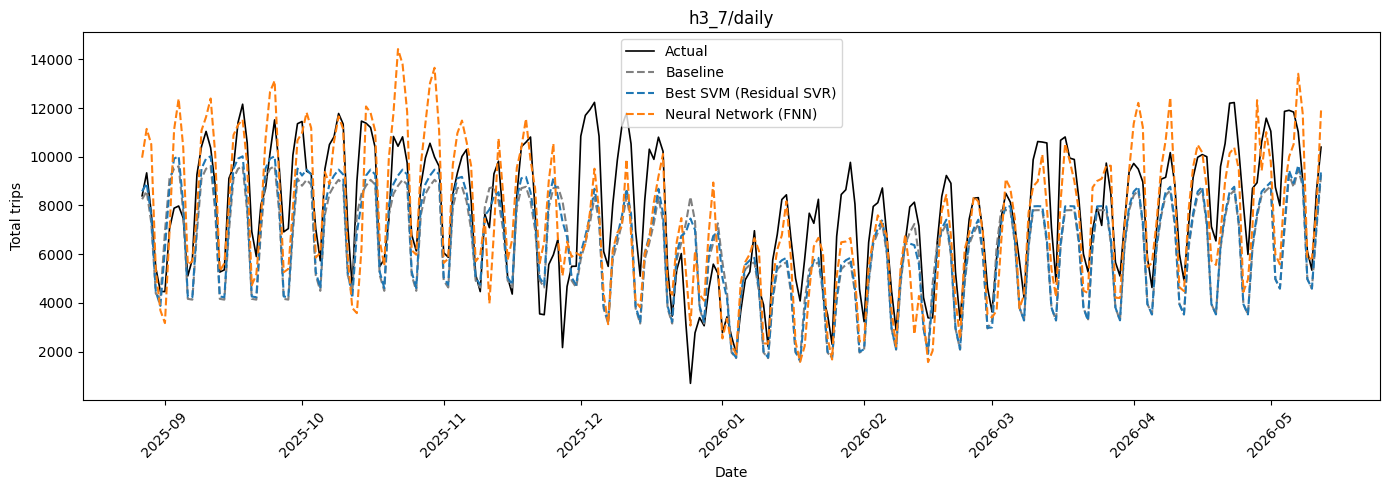

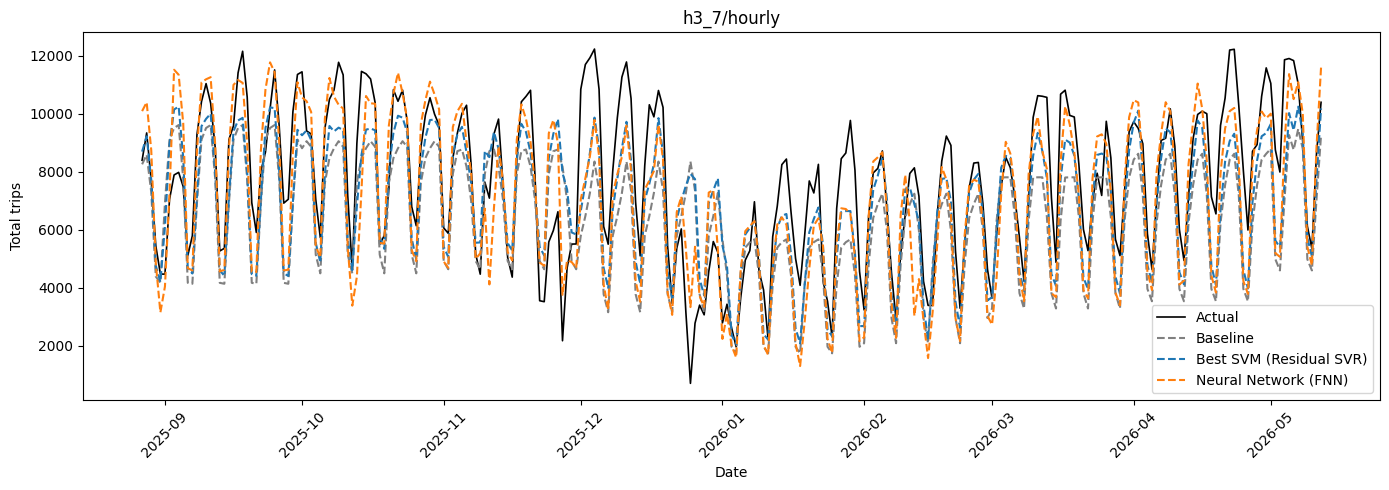

In [14]:
#| label: fig-svm-vs-nn-timeseries
#| fig-cap: "City-wide demand over the test period per temporal resolution."
#| fig-subcap:
#|   - "h3_7/daily"
#|   - "h3_7/hourly"
#| layout-ncol: 1
for temporal, testing_df in comparisons.items():
    ts = testing_df.copy()
    ts["date"] = pd.to_datetime(ts["timestamp"]).dt.date
    daily_agg = ts.groupby("date").agg(
        actual=(TRUTH, "sum"),
        baseline=(BASELINE_COL, "sum"),
    ).reset_index()
    for p in predictions.values():
        daily_agg[p["name"]] = ts.groupby("date")[p["col"]].sum().values

    fig, ax = plt.subplots(figsize=(14, 5))
    ax.set_title(f"h3_7/{temporal}")
    ax.plot(daily_agg["date"], daily_agg["actual"], label="Actual", color="black", linewidth=1.2)
    ax.plot(daily_agg["date"], daily_agg["baseline"], label="Baseline", linestyle="--", color="gray")
    for p in predictions.values():
        ax.plot(daily_agg["date"], daily_agg[p["name"]], label=p["name"], linestyle="--")
    ax.set_xlabel("Date")
    ax.set_ylabel("Total trips")
    ax.legend()
    plt.xticks(rotation=45)
    plt.tight_layout()
    plt.show()

## When does each model do best?

The maps above show *where* errors fall; this table shows *when*. It breaks test MAE down by
demand magnitude (zero / low / medium / high) and by weather (dry vs. rainy days), so a model that
wins overall but loses on, say, the busiest cells or on rainy days is not hidden behind a single
average. The same segmentation `3.6b` uses for the direct-vs-residual comparison.

In [15]:
#| label: tbl-svm-vs-nn-segments
#| tbl-cap: "Test MAE, relative error, and skill score by demand band and weather per temporal resolution."
#| tbl-subcap:
#|   - "h3_7/daily"
#|   - "h3_7/hourly"
def segment_masks(df, y):
    df["is_rainy"] = (df["total_precip_mm"] >= 0.1).astype(int)
    return {
        "all": np.ones(len(df), dtype=bool),
        "zero demand (y = 0)": y == 0,
        "low demand (1-10)": (y >= 1) & (y <= 10),
        "medium demand (11-100)": (y > 10) & (y <= 100),
        "high demand (> 100)": y > 100,
        "dry days": df["is_rainy"].values == 0,
        "rainy days": df["is_rainy"].values == 1,
    }

def row_rel_error(y_true, y_pred):
    """Per-row relative error |y_true - y_pred| / y_true; undefined (NaN) where y_true == 0."""
    with np.errstate(divide="ignore", invalid="ignore"):
        rel = np.abs(y_true - y_pred) / y_true
    return np.where(y_true == 0, np.nan, rel)

segment_tables = {}
segment_order = {}
for temporal, testing_df in comparisons.items():
    print(f"\n--- h3_7/{temporal} ---")
    y_true = testing_df[TRUTH].values
    rel_err_rows = {"Baseline": row_rel_error(y_true, testing_df[BASELINE_COL].values)}
    for p in predictions.values():
        rel_err_rows[p["name"]] = row_rel_error(y_true, testing_df[p["col"]].values)

    rows = []
    for seg_name, mask in segment_masks(testing_df, y_true).items():
        if mask.sum() == 0:
            continue
        mean_actual = y_true[mask].mean()
        rows.append({"segment": seg_name, "Model": "Baseline", "n": int(mask.sum()),
                     "mean_actual": mean_actual,
                     "MAE": mean_absolute_error(y_true[mask], testing_df[BASELINE_COL].values[mask]),
                     "rel_error": np.nanmean(rel_err_rows["Baseline"][mask])})
        for p in predictions.values():
            rows.append({"segment": seg_name, "Model": p["name"], "n": int(mask.sum()),
                         "mean_actual": mean_actual,
                         "MAE": mean_absolute_error(y_true[mask], testing_df[p["col"]].values[mask]),
                         "rel_error": np.nanmean(rel_err_rows[p["name"]][mask])})
    seg_df = pd.DataFrame(rows)
    baseline_mae = seg_df.loc[seg_df["Model"] == "Baseline"].set_index("segment")["MAE"]
    # Skill score vs. the historical-mean baseline: 1 = perfect, 0 = ties baseline, < 0 = worse than baseline.
    seg_df["skill_score"] = 1 - seg_df["MAE"] / seg_df["segment"].map(baseline_mae)
    segment_tables[temporal] = seg_df
    segment_order[temporal] = seg_df["segment"].unique().tolist()
    display(seg_df.drop(columns="mean_actual").set_index(["segment", "Model"]).round(3))


--- h3_7/daily ---


n      MAE  rel_error  \
segment                Model                                                
all                    Baseline                 27972   21.391      0.948   
                       Best SVM (Residual SVR)  27972   20.639      0.923   
                       Neural Network (FNN)     27972   20.152      0.736   
zero demand (y = 0)    Baseline                 22149    0.126        NaN   
                       Best SVM (Residual SVR)  22149    0.189        NaN   
                       Neural Network (FNN)     22149    0.188        NaN   
low demand (1-10)      Baseline                  2384    4.149      1.494   
                       Best SVM (Residual SVR)   2384    3.974      1.427   
                       Neural Network (FNN)      2384    2.990      1.058   
medium demand (11-100) Baseline                  1628   27.275      0.758   
                       Best SVM (Residual SVR)   1628   27.656      0.761   
                       Neural Network (FNN)      1628   24.402      0.633   
high demand (> 100)    Baseline                  1811  298.878      0.401   
                       Best SVM (Residual SVR)   1811  286.379      0.404   
                       Neural Network (FNN)      1811  283.091      0.404   
dry days               Baseline                 24732   21.422      0.961   
                       Best SVM (Residual SVR)  24732   20.616      0.933   
                       Neural Network (FNN)     24732   19.679      0.733   
rainy days             Baseline                  3240   21.160      0.847   
                       Best SVM (Residual SVR)   3240   20.814      0.848   
                       Neural Network (FNN)      3240   23.766      0.760   

                                                skill_score  
segment                Model                                 
all                    Baseline                       0.000  
                       Best SVM (Residual SVR)        0.035  
                       Neural Network (FNN)           0.058  
zero demand (y = 0)    Baseline                       0.000  
                       Best SVM (Residual SVR)       -0.499  
                       Neural Network (FNN)          -0.490  
low demand (1-10)      Baseline                       0.000  
                       Best SVM (Residual SVR)        0.042  
                       Neural Network (FNN)           0.279  
medium demand (11-100) Baseline                       0.000  
                       Best SVM (Residual SVR)       -0.014  
                       Neural Network (FNN)           0.105  
high demand (> 100)    Baseline                       0.000  
                       Best SVM (Residual SVR)        0.042  
                       Neural Network (FNN)           0.053  
dry days               Baseline                       0.000  
                       Best SVM (Residual SVR)        0.038  
                       Neural Network (FNN)           0.081  
rainy days             Baseline                       0.000  
                       Best SVM (Residual SVR)        0.016  
                       Neural Network (FNN)          -0.123


--- h3_7/hourly ---


n     MAE  rel_error  \
segment                Model                                                
all                    Baseline                 671328   1.068      0.746   
                       Best SVM (Residual SVR)  671328   1.016      0.738   
                       Neural Network (FNN)     671328   0.977      0.704   
zero demand (y = 0)    Baseline                 620830   0.043        NaN   
                       Best SVM (Residual SVR)  620830   0.107        NaN   
                       Neural Network (FNN)     620830   0.031        NaN   
low demand (1-10)      Baseline                  26513   3.324      1.026   
                       Best SVM (Residual SVR)   26513   3.321      1.028   
                       Neural Network (FNN)      26513   3.171      0.939   
medium demand (11-100) Baseline                  17335  15.334      0.507   
                       Best SVM (Residual SVR)   17335  14.823      0.494   
                       Neural Network (FNN)      17335  15.912      0.527   
high demand (> 100)    Baseline                   6650  50.534      0.256   
                       Best SVM (Residual SVR)    6650  40.714      0.215   
                       Neural Network (FNN)       6650  41.552      0.231   
dry days               Baseline                 590544   1.058      0.746   
                       Best SVM (Residual SVR)  590544   1.004      0.736   
                       Neural Network (FNN)     590544   0.966      0.698   
rainy days             Baseline                  80784   1.143      0.749   
                       Best SVM (Residual SVR)   80784   1.110      0.752   
                       Neural Network (FNN)      80784   1.057      0.742   

                                                skill_score  
segment                Model                                 
all                    Baseline                       0.000  
                       Best SVM (Residual SVR)        0.048  
                       Neural Network (FNN)           0.085  
zero demand (y = 0)    Baseline                       0.000  
                       Best SVM (Residual SVR)       -1.482  
                       Neural Network (FNN)           0.277  
low demand (1-10)      Baseline                       0.000  
                       Best SVM (Residual SVR)        0.001  
                       Neural Network (FNN)           0.046  
medium demand (11-100) Baseline                       0.000  
                       Best SVM (Residual SVR)        0.033  
                       Neural Network (FNN)          -0.038  
high demand (> 100)    Baseline                       0.000  
                       Best SVM (Residual SVR)        0.194  
                       Neural Network (FNN)           0.178  
dry days               Baseline                       0.000  
                       Best SVM (Residual SVR)        0.051  
                       Neural Network (FNN)           0.087  
rainy days             Baseline                       0.000  
                       Best SVM (Residual SVR)        0.028  
                       Neural Network (FNN)           0.075

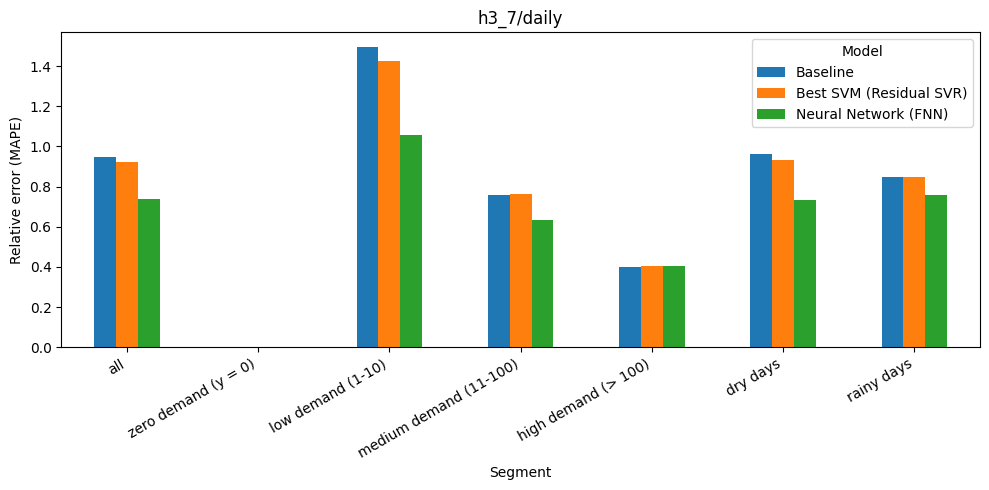

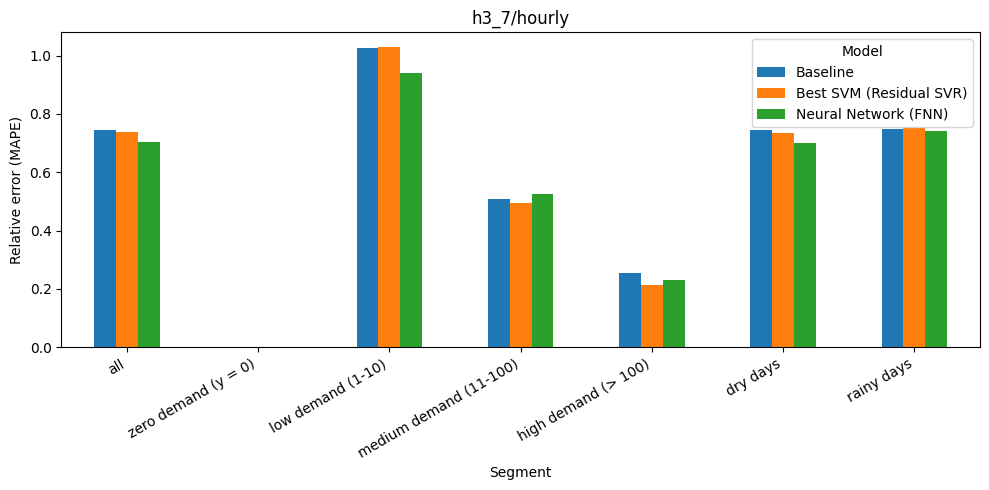

In [16]:
#| label: fig-svm-vs-nn-segments-relerr
#| fig-cap: "Test relative error (MAE / mean demand) by segment per temporal resolution."
#| fig-subcap:
#|   - "h3_7/daily"
#|   - "h3_7/hourly"
#| layout-ncol: 1
model_order = ["Baseline"] + [p["name"] for p in predictions.values()]
for temporal, seg_df in segment_tables.items():
    pivot = seg_df.pivot(index="segment", columns="Model", values="rel_error")
    pivot = pivot.loc[segment_order[temporal], model_order]

    fig, ax = plt.subplots(figsize=(10, 5))
    pivot.plot(kind="bar", ax=ax)
    ax.set_title(f"h3_7/{temporal}")
    ax.set_xlabel("Segment")
    ax.set_ylabel("Relative error (MAPE)")
    ax.legend(title="Model")
    plt.xticks(rotation=30, ha="right")
    plt.tight_layout()
    plt.show()